# LAB 4: KEYPOINT DETECTION


## 1. Khai báo thư viện

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as Phat

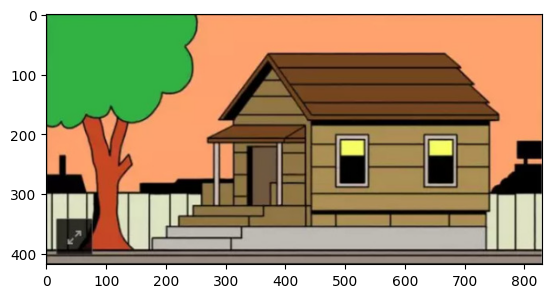

In [4]:
img = cv2.imread('image.png')
Phat.imshow(img[:,:,::-1])

## 2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh

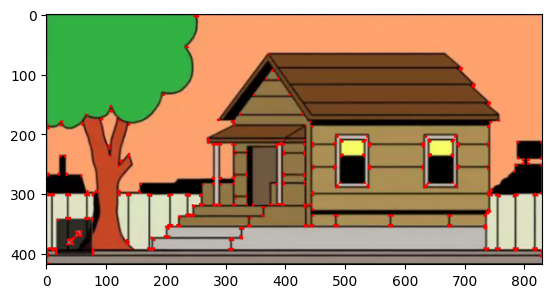

In [5]:
filename = 'image.png'
img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

dst = cv2.cornerHarris(gray, 2, 3, 0.04)
dst = cv2.dilate(dst, None)
img[dst > 0.01 * dst.max()] = [0, 0, 255]

Phat.imshow(img[:, :, ::-1])
Phat.show()


## 3. Sử dụng Band-pass filtering by Difference of Gaussiansan

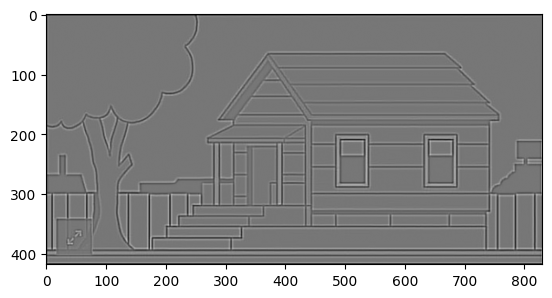

In [6]:
blur1 = cv2.GaussianBlur(gray, (5, 5), sigmaX=1.0)
blur2 = cv2.GaussianBlur(gray, (5, 5), sigmaX=2.0)
dog = blur1 - blur2

dog_normalized = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

Phat.imshow(dog_normalized, cmap='gray')
Phat.show()

## 4. Kiểm tra ảnh qua Automatic Scale Selection

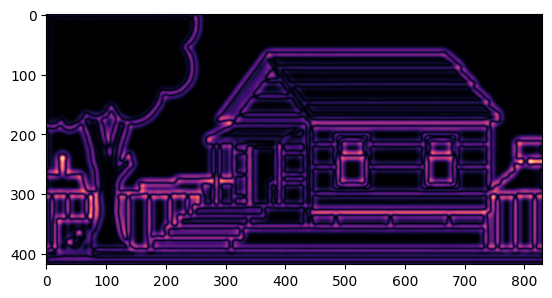

In [7]:
gray_float = gray.astype(np.float32) / 255.0

sigma = 4
ksize = int(6 * sigma + 1)
if ksize % 2 == 0: ksize += 1

blur = cv2.GaussianBlur(gray_float, (ksize, ksize), sigma)
log_normalized = cv2.Laplacian(blur, cv2.CV_32F) * (sigma**2)
result = np.abs(log_normalized)

Phat.imshow(result, cmap='magma')
Phat.show()

## 5. Kiểm tra ảnh qua Scale Invariant Detection

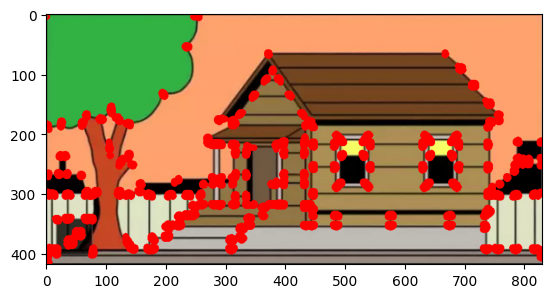

In [8]:
sigma = 3
ksize = int(6 * sigma + 1)
if ksize % 2 == 0: ksize += 1

dst = cv2.cornerHarris(gray_float, blockSize=int(2*sigma), ksize=3, k=0.04)
dst = cv2.dilate(dst, None)

result_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
threshold = 0.01 * dst.max()
corners = np.where(dst > threshold)

radius = int(sigma * np.sqrt(2))
for y, x in zip(corners[0], corners[1]):
    cv2.circle(result_img, (x, y), radius, (255, 0, 0), 1)

Phat.imshow(result_img)
Phat.show()

## 6. Kiểm tra ảnh qua Scale-space blob detector

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


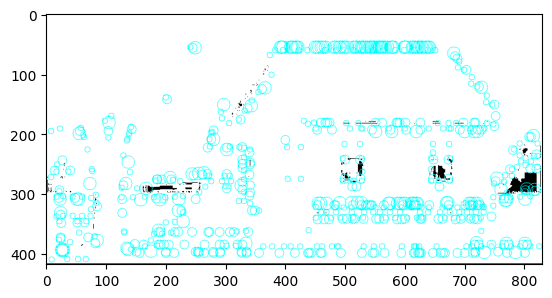

In [9]:
sigmas = [2, 4, 6, 8, 10]
scale_space = []

for sigma in sigmas:
    ksize = int(6 * sigma + 1)
    if ksize % 2 == 0: ksize += 1
    blur = cv2.GaussianBlur(gray_float, (ksize, ksize), sigma)
    log = cv2.Laplacian(blur, cv2.CV_32F) * (sigma**2)
    scale_space.append(np.abs(log))

scale_space = np.array(scale_space)

result_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
threshold = 0.1

for i in range(1, len(sigmas) - 1):
    layer = scale_space[i]
    for y in range(1, layer.shape[0]-1):
        for x in range(1, layer.shape[1]-1):
            val = layer[y, x]
            if val > threshold and val == np.max(scale_space[i-1:i+2, y-1:y+2, x-1:x+2]):
                radius = int(sigmas[i] * np.sqrt(2))
                cv2.circle(result_img, (x, y), radius, (0, 255, 255), 1)

Phat.imshow(result_img)
Phat.show()

## 7. Thực hành với Bag-of-words detection

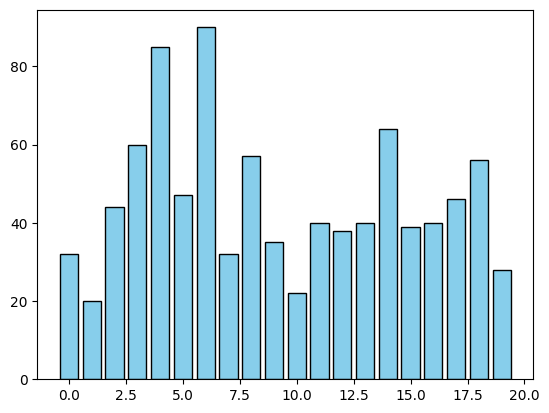

In [10]:
from sklearn.cluster import KMeans

sift = cv2.SIFT_create()

img = cv2.imread('image.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
keypoints, descriptors = sift.detectAndCompute(gray, None)

k = 20
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
kmeans.fit(descriptors)

labels = kmeans.predict(descriptors)
hist, _ = np.histogram(labels, bins=range(k + 1))

Phat.bar(range(k), hist, color='skyblue', edgecolor='black')
Phat.show()

## 8. Ghép ảnh Image Panoramas

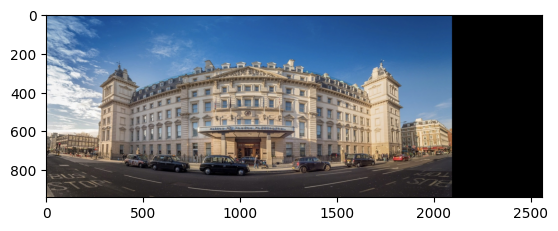

In [11]:
img_left = cv2.imread('left.jpg')
img_right = cv2.imread('right.jpg')

gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray_left, None)
kp2, des2 = sift.detectAndCompute(gray_right, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

if len(good_matches) > 10:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

    width = img_left.shape[1] + img_right.shape[1]
    height = img_left.shape[0]

    result = cv2.warpPerspective(img_right, H, (width, height))
    result[0:img_left.shape[0], 0:img_left.shape[1]] = img_left

    Phat.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    Phat.show()
else:
    print("Không ghép ảnh được")

## 9. Ghép ảnh Automatic mosaicing

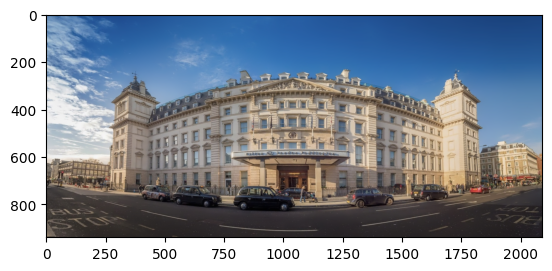

In [12]:
filenames = ['left.jpg', 'middle.jpg', 'right.jpg']
images = []

for file in filenames:
    img = cv2.imread(file)
    if img is not None:
        images.append(img)

stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
status, result = stitcher.stitch(images)

if status == cv2.Stitcher_OK:
    result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    Phat.imshow(result_rgb)
    Phat.show()
else:
    print("Không ghép ảnh được")

## 10. Sử dụng Wide base-line stereo

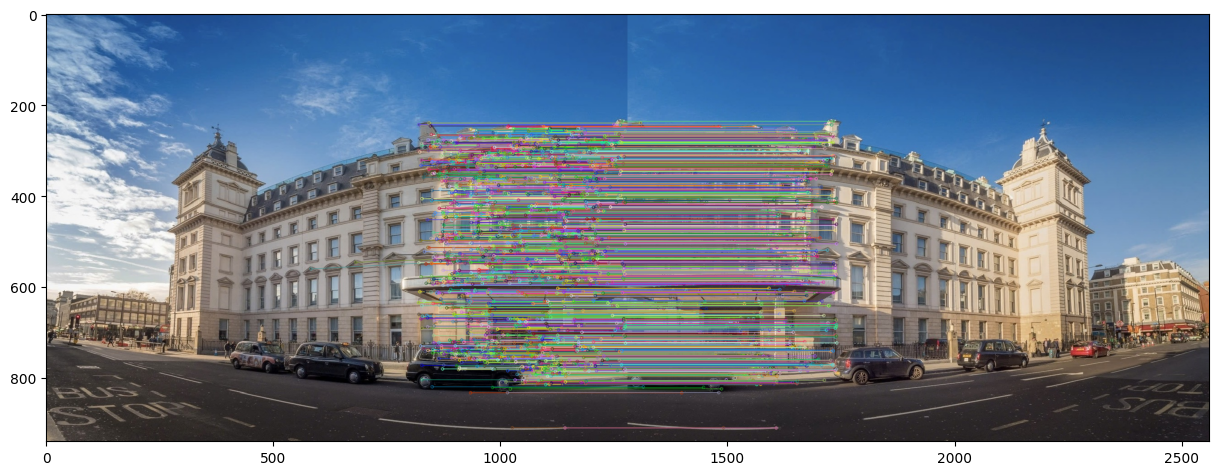

In [16]:
img1 = cv2.imread('left.jpg')
img2 = cv2.imread('right.jpg')

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

pts1 = []
pts2 = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        pts1.append(kp1[m.queryIdx].pt)
        pts2.append(kp2[m.trainIdx].pt)

if len(pts1) >= 8:
    pts1 = np.float32(pts1).reshape(-1, 1, 2)
    pts2 = np.float32(pts2).reshape(-1, 1, 2)

    F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 3.0, 0.99)

    if mask is not None:
        mask_bool = mask.ravel() == 1
        pts1_in = pts1[mask_bool]
        pts2_in = pts2[mask_bool]

        kp1_res = [cv2.KeyPoint(p[0][0], p[0][1], 1) for p in pts1_in]
        kp2_res = [cv2.KeyPoint(p[0][0], p[0][1], 1) for p in pts2_in]
        matches_res = [cv2.DMatch(i, i, 0) for i in range(len(pts1_in))]

        res = cv2.drawMatches(img1, kp1_res, img2, kp2_res, matches_res, None, 
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

        Phat.figure(figsize=(15, 8))
        Phat.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
        Phat.show()
    else:
        print("Không tìm thấy Ma trận cơ bản.")
else:
    print(f"Không đủ điểm khớp (Chỉ tìm thấy {len(pts1)} điểm).")

## 11. CBIR (content-based image retrieval)

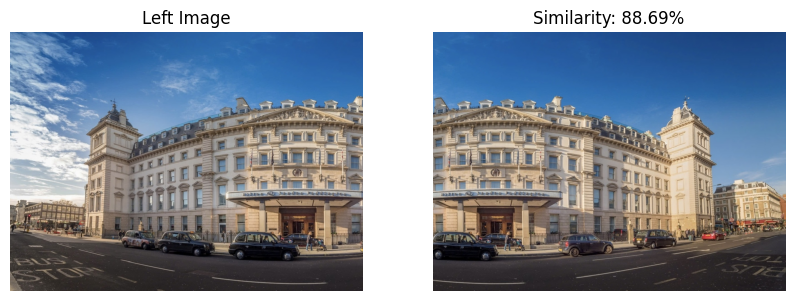

In [14]:
img1 = cv2.imread('left.jpg')
img2 = cv2.imread('right.jpg')

if img1 is None or img2 is None:
    print("Vui lòng kiểm tra lại tên file left.jpg hoặc right.jpg!")
else:
    hsv_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2HSV)
    hsv_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)

    hist1 = cv2.calcHist([hsv_img1], [0, 1], None, [50, 60], [0, 180, 0, 256])
    hist2 = cv2.calcHist([hsv_img2], [0, 1], None, [50, 60], [0, 180, 0, 256])

    cv2.normalize(hist1, hist1, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    cv2.normalize(hist2, hist2, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

    similarity = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)

    Phat.figure(figsize=(10, 5))

    Phat.subplot(1, 2, 1)
    Phat.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    Phat.title('Left Image')
    Phat.axis('off')

    Phat.subplot(1, 2, 2)
    Phat.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    Phat.title(f'Similarity: {similarity*100:.2f}%')
    Phat.axis('off')

    Phat.show()

## 12. Bag-of-word with SIFT + Histogram

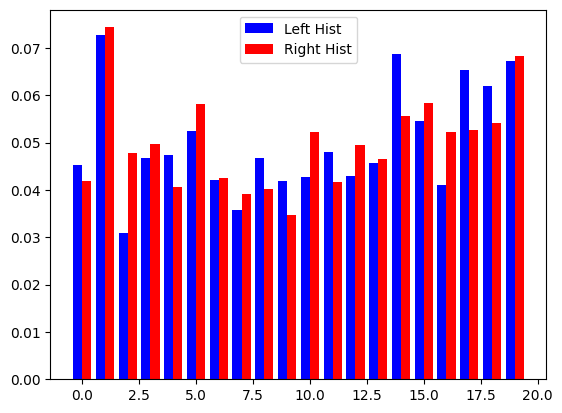

In [15]:
from sklearn.cluster import KMeans

sift = cv2.SIFT_create()

def get_descriptors(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, des = sift.detectAndCompute(gray, None)
    return des

img_left = cv2.imread('left.jpg')
img_right = cv2.imread('right.jpg')

des_left = get_descriptors(img_left)
des_right = get_descriptors(img_right)

all_des = np.vstack((des_left, des_right))
k = 20
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0).fit(all_des)

def build_histogram(descriptors, kmeans, k):
    labels = kmeans.predict(descriptors)
    hist, _ = np.histogram(labels, bins=range(k + 1))
    return hist.astype(float) / np.sum(hist)

hist_left = build_histogram(des_left, kmeans, k)
hist_right = build_histogram(des_right, kmeans, k)

distance = np.linalg.norm(hist_left - hist_right)

x = np.arange(k)
Phat.bar(x - 0.2, hist_left, width=0.4, label='Left Hist', color='blue')
Phat.bar(x + 0.2, hist_right, width=0.4, label='Right Hist', color='red')
Phat.legend()

Phat.show()